🏏 IPL 2022 Data Analysis Project

The Indian Premier League (IPL) is one of the most popular T20 cricket leagues in the world. It features franchise teams representing different cities in India.

In this project, we analyze IPL 2022 match-level data to derive meaningful insights about:

.Match outcomes

.Player performances

.Team strategies and dynamics

.Toss decisions and their impact on winning

.The dataset contains information about matches such as teams playing, match venue, toss results, scores, and player performances.

In [73]:
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt 
import seaborn as sns 
import warnings
warnings.filterwarnings('ignore')
df=pd.read_csv('IPL.csv')
df.head()


,match_id,date,venue,team1,team2,stage,toss_winner,toss_decision,first_ings_score,first_ings_wkts,second_ings_score,second_ings_wkts,match_winner,won_by,margin,player_of_the_match,top_scorer,highscore,best_bowling,best_bowling_figure
0,1,"March 26,2022","Wankhede Stadium, Mumbai",Chennai,Kolkata,Group,Kolkata,Field,131,5,133,4,Kolkata,Wickets,6,Umesh Yadav,MS Dhoni,50,Dwayne Bravo,3--20
1,2,"March 27,2022","Brabourne Stadium, Mumbai",Delhi,Mumbai,Group,Delhi,Field,177,5,179,6,Delhi,Wickets,4,Kuldeep Yadav,Ishan Kishan,81,Kuldeep Yadav,3--18
2,3,"March 27,2022","Dr DY Patil Sports Academy, Mumbai",Banglore,Punjab,Group,Punjab,Field,205,2,208,5,Punjab,Wickets,5,Odean Smith,Faf du Plessis,88,Mohammed Siraj,2--59
3,4,"March 28,2022","Wankhede Stadium, Mumbai",Gujarat,Lucknow,Group,Gujarat,Field,158,6,161,5,Gujarat,Wickets,5,Mohammed Shami,Deepak Hooda,55,Mohammed Shami,3--25
4,5,"March 29,2022","Maharashtra Cricket Association Stadium,Pune",Hyderabad,Rajasthan,Group,Hyderabad,Field,210,6,149,7,Rajasthan,Runs,61,Sanju Samson,Aiden Markram,57,Yuzvendra Chahal,3--22


BASIC INFORAMATION

In [74]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 74 entries, 0 to 73
Data columns (total 20 columns):
 #   Column               Non-Null Count  Dtype 
---  ------               --------------  ----- 
 0   match_id             74 non-null     int64 
 1   date                 74 non-null     object
 2   venue                74 non-null     object
 3   team1                74 non-null     object
 4   team2                74 non-null     object
 5   stage                74 non-null     object
 6   toss_winner          74 non-null     object
 7   toss_decision        74 non-null     object
 8   first_ings_score     74 non-null     int64 
 9   first_ings_wkts      74 non-null     int64 
 10  second_ings_score    74 non-null     int64 
 11  second_ings_wkts     74 non-null     int64 
 12  match_winner         74 non-null     object
 13  won_by               74 non-null     object
 14  margin               74 non-null     int64 
 15  player_of_the_match  74 non-null     object
 16  top_scorer

check the size of rows and columns of dataset

In [75]:
print(f"your rows are {df.shape[0]} and your columns are {df.shape[1]}")

your rows are 74 and your columns are 20


Now let's see how many columns have null values in total.

In [76]:
df.isnull().sum() #zero null values

match_id               0
date                   0
venue                  0
team1                  0
team2                  0
stage                  0
toss_winner            0
toss_decision          0
first_ings_score       0
first_ings_wkts        0
second_ings_score      0
second_ings_wkts       0
match_winner           0
won_by                 0
margin                 0
player_of_the_match    0
top_scorer             0
highscore              0
best_bowling           0
best_bowling_figure    0
dtype: int64

1. Which team won the most matches?

In [77]:
match_wins=df['match_winner'].value_counts()
match_wins

match_winner
Gujarat      12
Rajasthan    10
Banglore      9
Lucknow       9
Delhi         7
Punjab        7
Kolkata       6
Hyderabad     6
Chennai       4
Mumbai        4
Name: count, dtype: int64

Text(0.5, 1.0, 'Most Match win by team')

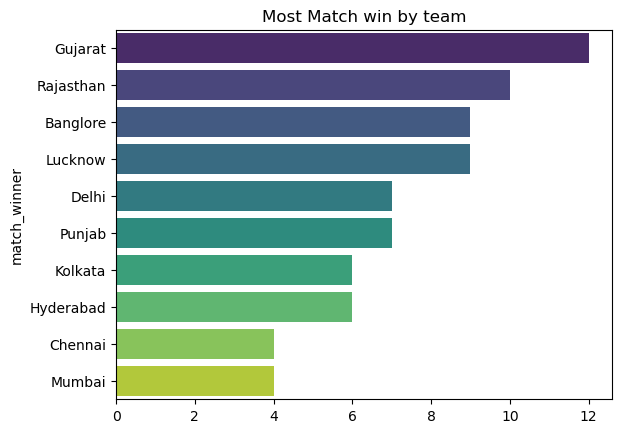

In [78]:
sns.barplot(x=match_wins.values,y=match_wins.index,palette='viridis')
plt.title("Most Match win by team")

2.Toss Decision Trends

Text(0.5, 1.0, 'Toss Decision Trends')

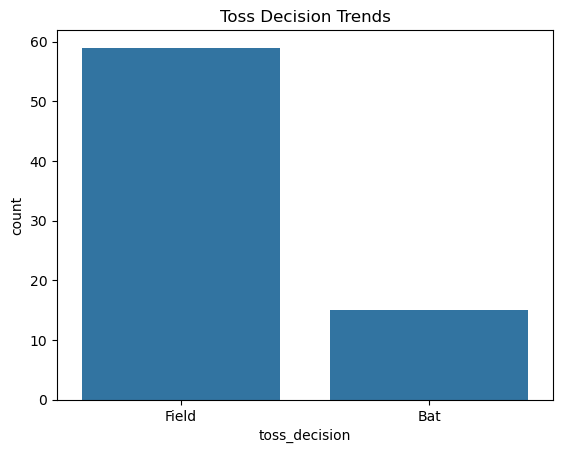

In [79]:
sns.countplot(x='toss_decision',data=df)
plt.title("Toss Decision Trends")

3.Toss Winner vs Match Winner

In [80]:
count = (df['toss_winner'] == df['match_winner']).sum()
print("count",count)
percentage = round((count*100)/len(df),2)
print("percentage",percentage)

count 36
percentage 48.65


4.How do teams win? (Runs vs Wickets)

In [81]:
wicket=(df["won_by"]=='Wickets').sum()
percentage_w=(wicket*100)/len(df)
print('won by wicket',percentage_w)

won by wicket 50.0


Text(0.5, 1.0, 'WON BY')

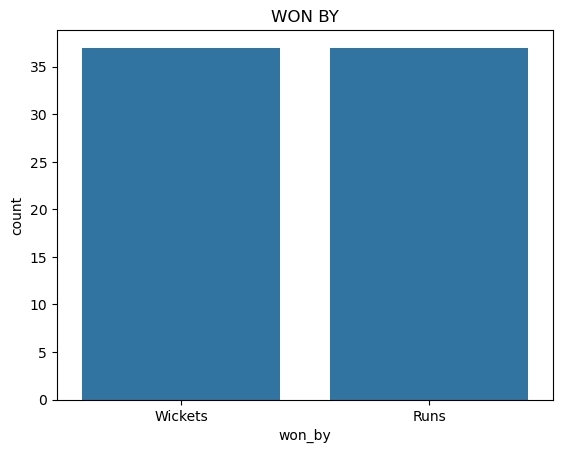

In [82]:
sns.countplot(x='won_by',data=df)
plt.title("WON BY")

Key Player Performances

1.Most "Player of the Match" Awards

In [83]:
player=df['player_of_the_match'].value_counts().head(10)
print(f"player name {player.idxmax()} got most award: {player.max()}")

player name Kuldeep Yadav got most award: 4


Text(0.5, 1.0, 'Top 10 player With Man of the Match')

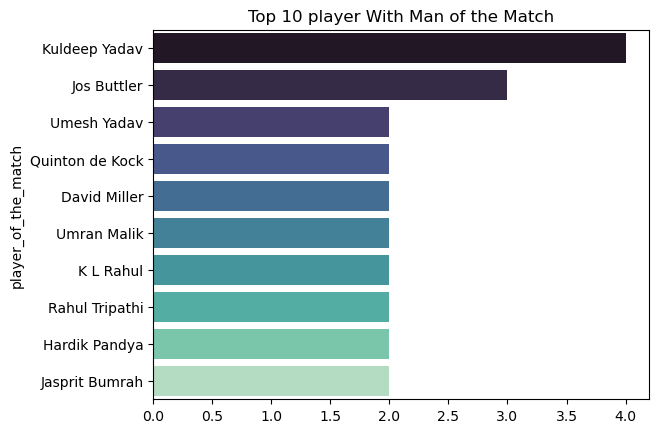

In [84]:
sns.barplot(x=player.values,y=player.index,palette='mako')
plt.title("Top 10 player With Man of the Match")

2 Top Scorers

In [85]:
top2 = df.nlargest(2, 'highscore')[['top_scorer','highscore']]
print(top2)

         top_scorer  highscore
65  Quinton de Kock        140
33      Jos Buttler        116


In [86]:
df.head()

,match_id,date,venue,team1,team2,stage,toss_winner,toss_decision,first_ings_score,first_ings_wkts,second_ings_score,second_ings_wkts,match_winner,won_by,margin,player_of_the_match,top_scorer,highscore,best_bowling,best_bowling_figure
0,1,"March 26,2022","Wankhede Stadium, Mumbai",Chennai,Kolkata,Group,Kolkata,Field,131,5,133,4,Kolkata,Wickets,6,Umesh Yadav,MS Dhoni,50,Dwayne Bravo,3--20
1,2,"March 27,2022","Brabourne Stadium, Mumbai",Delhi,Mumbai,Group,Delhi,Field,177,5,179,6,Delhi,Wickets,4,Kuldeep Yadav,Ishan Kishan,81,Kuldeep Yadav,3--18
2,3,"March 27,2022","Dr DY Patil Sports Academy, Mumbai",Banglore,Punjab,Group,Punjab,Field,205,2,208,5,Punjab,Wickets,5,Odean Smith,Faf du Plessis,88,Mohammed Siraj,2--59
3,4,"March 28,2022","Wankhede Stadium, Mumbai",Gujarat,Lucknow,Group,Gujarat,Field,158,6,161,5,Gujarat,Wickets,5,Mohammed Shami,Deepak Hooda,55,Mohammed Shami,3--25
4,5,"March 29,2022","Maharashtra Cricket Association Stadium,Pune",Hyderabad,Rajasthan,Group,Hyderabad,Field,210,6,149,7,Rajasthan,Runs,61,Sanju Samson,Aiden Markram,57,Yuzvendra Chahal,3--22


10 best Bowling figure

In [87]:
df[['wickets','runs']] = df['best_bowling_figure'].str.split('--',expand=True).astype(int)

top10 = df.sort_values(['wickets','runs'],ascending=[False,True]).head(10)

print(top10[['best_bowling','best_bowling_figure']])

         best_bowling best_bowling_figure
55     Jasprit Bumrah               5--10
53  Wanindu Hasaranga               5--18
39        Umran Malik               5--25
29   Yuzvendra Chahal               5--40
34      Andre Russell                4--5
40      Kuldeep Yadav               4--14
44        Mohsin Khan               4--16
5   Wanindu Hasaranga               4--20
38        Kuldeep Sen               4--20
7         Umesh Yadav               4--23


Venue Analysis

Most Matches Played by Venue

In [91]:
venue_count = df['venue'].value_counts()
venue_count


venue
Wankhede Stadium, Mumbai                        21
Dr DY Patil Sports Academy, Mumbai              20
Brabourne Stadium, Mumbai                       16
Maharashtra Cricket Association Stadium,Pune    13
Eden Gardens, Kolkata                            2
Narendra Modi Stadium, Ahmedabad                 2
Name: count, dtype: int64

<Axes: ylabel='venue'>

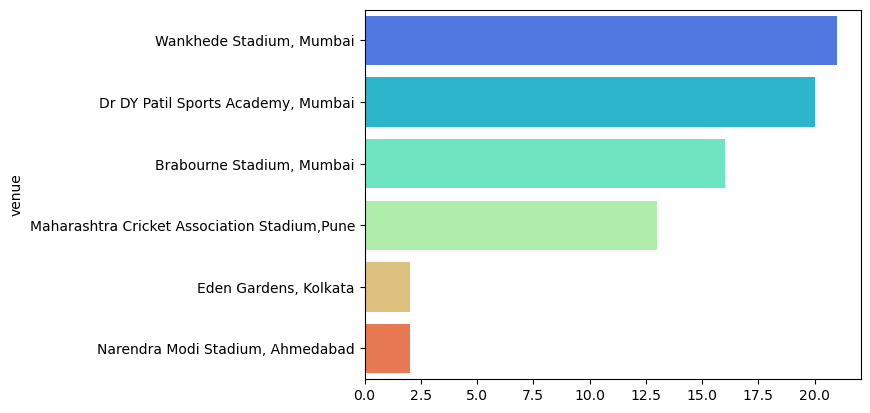

In [92]:
sns.barplot(y = venue_count.index,x = venue_count.values,palette='rainbow')

Custom Questions & Insights

Q1: Who won the highest margin by runs?

In [103]:
wonby_run=df[df['won_by']=='Runs']
wonby_run.nlargest(1,'margin')[['match_winner','margin']]


,match_winner,margin
54,Chennai,91


Q2: Which player had the highest individual score?

In [105]:
df.nlargest(1,"highscore")['top_scorer']

65    Quinton de Kock
Name: top_scorer, dtype: object

Q3: Which bowler had the best bowling figures?

In [112]:
top=df.sort_values(['wickets','runs'],ascending=[False,True]).head(1)
top[['best_bowling','best_bowling_figure']]

,best_bowling,best_bowling_figure
55,Jasprit Bumrah,5--10
